# Credit Card Customer Segmentation

This project uses K-Means Clustering to group credit card customers based on their financial behavior, such as balance, purchases, and credit limit, without using any predefined labels. The resulting clusters help identify distinct customer segments, enabling targeted marketing and personalized financial strategies.

In [139]:
#Step 1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [140]:
#Step 2
#Load Dataset
df=pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [141]:
#Step 3
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [142]:
#Step 4
#Check Missing Values
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [143]:
#Step 5
#Fill Missing Values
df["MINIMUM_PAYMENTS"]=df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].mean())
df["CREDIT_LIMIT"]=df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].mean())

In [144]:
#Step 6
#Verify
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [145]:
#Step 7
#Select Relevant Features
X=df[["BALANCE","PURCHASES","CREDIT_LIMIT","PAYMENTS","MINIMUM_PAYMENTS"]]

In [146]:
#Step 8
#Feature Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [147]:
#Step 9
#Implementation
X_scaled=sc.fit_transform(X)

In [148]:
#Step 10
#Elbow Method
#for finding best inertia
inertia=[]
K_range=range(1,11)
for k in K_range:
  KMeans_model=KMeans(n_clusters=k,random_state=42)
  KMeans_model.fit(X_scaled)
  inertia.append(KMeans_model.inertia_)

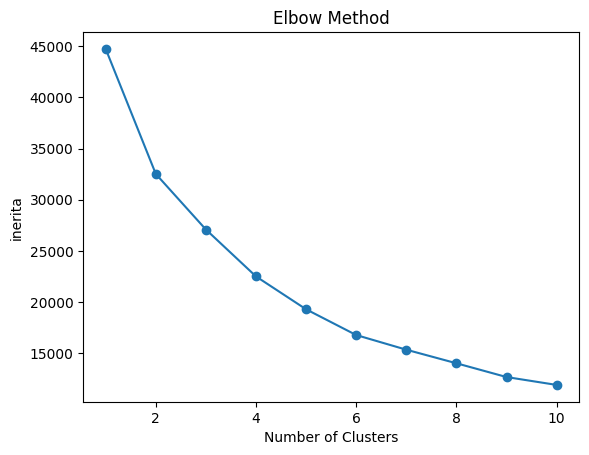

In [149]:
#Step 11
#PLot the best K
plt.plot(K_range,inertia,marker='o')
plt.title('Elbow Method')
plt.xlabel("Number of Clusters")
plt.ylabel("inerita")
plt.show()

In [150]:
#Step 12
#Train with best k
KMeans_final=KMeans(n_clusters=4,random_state=42,n_init="auto")
KMeans_final.fit(X_scaled)

KMeans(n_clusters=4, random_state=42)

In [151]:
#Step 13
#Add Cluster Labels to Data
clusters = KMeans_final.labels_
df["cluster"]=clusters

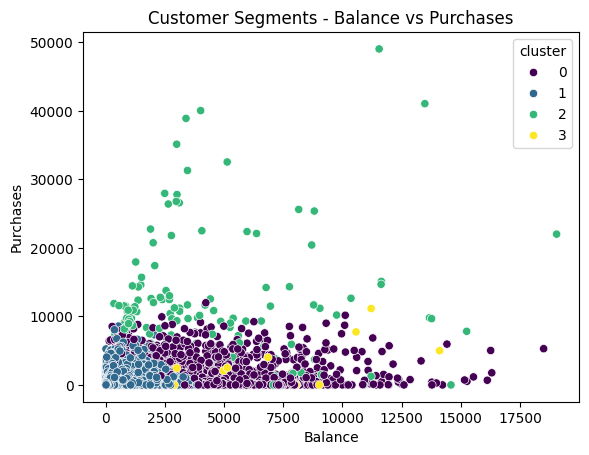

In [152]:
#Step 14
#Visualizations
#TO see if clustering occured
sns.scatterplot(x=df['BALANCE'], y=df['PURCHASES'], hue=df['cluster'], palette='viridis')
plt.title('Customer Segments - Balance vs Purchases')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.show()

In [153]:
#Step 15
#Analyze Each Cluster
df.groupby('cluster')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']].mean()

,BALANCE,PURCHASES,CREDIT_LIMIT,PAYMENTS
cluster,,,,
0,4278.829702,1558.963990,9204.814038,3068.150014
1,800.664947,654.490777,3138.214720,1079.711879
2,4227.179215,10867.563630,11949.657534,16669.510976
3,4584.288783,1206.521707,4881.707317,2022.417327


### Business Insights

**Cluster 0 (Moderate Spenders):** Customers with a decent credit limit but relatively low purchases. There is potential to increase engagement through targeted spending incentives.

**Cluster 1 (Low Activity Customers):** This segment shows the lowest balance, purchases, and credit limit, suggesting newer or less engaged customers. Onboarding offers and welcome incentives could help activate this group.

**Cluster 2 (Premium High Spenders):** These customers have the highest purchases, credit limit, and payments, making them the most valuable segment. They should be prioritized for VIP treatment, exclusive rewards, and credit limit upgrades.

**Cluster 3 (High Balance, Low Spenders):** Customers who maintain a high balance but make relatively few purchases. Targeted offers or investment products could encourage them to utilize their available funds more actively.

Overall, Cluster 2 represents the most valuable customer segment, while Cluster 1 requires the most attention to drive engagement.